# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.6 MB/s eta 0:00:00
✅ Dependencies ready


In [2]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [3]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "information": 0,
    "opinion":     1,
    "reaction":    2,
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'information': 0, 'opinion': 1, 'reaction': 2}
Number of labels: 3


In [4]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving labeled.csv to labeled.csv
Uploaded: labeled.csv


In [5]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# Keep only rows that have actually been labeled (annotation in progress is fine).
df = df[df["label"].notna() & (df["label"].astype(str).str.strip() != "")].copy()
df["label"] = df["label"].str.strip()
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Distribution + balance checks
counts = df["label"].value_counts()
n = len(df)
print("\nLabel distribution:")
for lab, c in counts.items():
    print(f"  {lab:12} {c:4}  ({c / n:5.1%})")

top_frac = counts.max() / n
low_frac = min(counts.get(l, 0) / n for l in LABEL_MAP)
print(f"\n{'⚠️' if n < 200 else '✅'} {n} examples (need ≥200)")
print(f"{'⚠️' if top_frac > 0.70 else '✅'} largest class = {top_frac:.1%} (must be ≤70%)")
print(f"{'⚠️' if low_frac < 0.20 else '✅'} smallest class = {low_frac:.1%} (target ≥20%)")

# Override rate vs. Groq prelabels (for the AI usage section)
if "prelabel" in df.columns:
    both = df[df["prelabel"].notna() & (df["prelabel"].astype(str).str.strip() != "")]
    if len(both):
        changed = (both["label"] != both["prelabel"].str.strip()).sum()
        print(f"\nReviewed {len(both)} pre-labeled rows; overrode {changed} "
              f"({changed / len(both):.1%}).")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['id', 'thread', 'score', 'words', 'text', 'prelabel', 'label', 'notes']
Total examples: 230

Label distribution:
label
opinion        119
reaction        58
information     53
Name: count, dtype: int64

✅ All labels match your LABEL_MAP

Label distribution:
  opinion       119  (51.7%)
  reaction       58  (25.2%)
  information    53  (23.0%)

✅ 230 examples (need ≥200)
✅ largest class = 51.7% (must be ≤70%)
✅ smallest class = 23.0% (target ≥20%)

Reviewed 230 pre-labeled rows; overrode 43 (18.7%).


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [6]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 161 examples
Validation: 34 examples
Test: 35 examples

Train label distribution:
label
opinion        83
reaction       41
information    37
Name: count, dtype: int64

Test label distribution:
label
opinion        18
reaction        9
information     8
Name: count, dtype: int64


In [7]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/161 [00:00<?, ? examples/s]

Map:   0%|          | 0/34 [00:00<?, ? examples/s]

Map:   0%|          | 0/35 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [12]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [13]:
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        # macro-F1 weights each class equally, so poor performance on the rare
        # `information` class shows up — this is the metric we optimize for.
        "f1_macro": f1_score(labels, predictions, average="macro"),
    }

In [14]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.124491,1.110924,0.235294,0.126984
2,1.102730,1.055893,0.588235,0.373333
3,1.042578,0.988845,0.529412,0.230769


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [15]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Headline metrics
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
ft_f1_macro = f1_score(ft_true_ids, ft_pred_ids, average="macro")
print(f"\n🎯 Fine-tuned model — accuracy: {ft_accuracy:.3f}   macro-F1: {ft_f1_macro:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model — accuracy: 0.543   macro-F1: 0.338

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

 information       0.00      0.00      0.00         8
     opinion       0.53      0.94      0.68        18
    reaction       0.67      0.22      0.33         9

    accuracy                           0.54        35
   macro avg       0.40      0.39      0.34        35
weighted avg       0.44      0.54      0.44        35



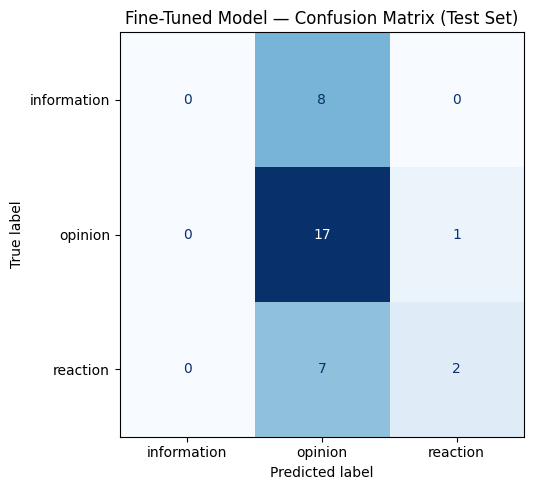

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [16]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [17]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 16 / 35

--- #1 ---
Text:      The unredacted body cam footage was leaked on a public Dropbox for about 40mins - someone grabbed it before it got took down and posted it on YouTube. The channel is called BAM Sucks.
True:      information
Predicted: opinion  (confidence: 0.34)

--- #2 ---
Text:      God this situation is so messy, all they had to do was hand the collection back. But a CEO is gonna CEO 🤷‍♂️
True:      reaction
Predicted: opinion  (confidence: 0.37)

--- #3 ---
Text:      Downvote bricks and mini figs on Google until they give it back .All of them.
True:      reaction
Predicted: opinion  (confidence: 0.36)

--- #4 ---
Text:      Never heard of these YouTubers but if Matt "fertile 16 year olds" Walsh doesn't like them then that already is a glowing review. Just wish I got to see the video first, any reuploads anywhere?
True:      reaction
Predicted: opinion  (confidence: 0.36)

--- #5 ---
Text:      LEGO has a official partnership with Bricks and Minifig

In [ ]:
# Sample classifications for the README (mix of correct + incorrect, with confidence).
print("Sample classifications (fine-tuned model):\n")
for idx in range(min(8, len(test_df))):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    conf = ft_probs[idx][ft_pred_ids[idx]]
    mark = "OK " if pred_label == true_label else "ERR"
    print(f"{mark} pred={pred_label:11} conf={conf:.2f}  true={true_label:11} | {text[:85]}")

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [8]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [9]:
# Zero-shot classification prompt for the Groq baseline.
# Definitions + examples mirror planning.md so the baseline is judged on the
# SAME taxonomy as the fine-tuned model. Output is constrained to one label.

SYSTEM_PROMPT = """You classify comments from r/youtubedrama, a subreddit about \
conflicts and controversies between online creators. Assign each comment to \
exactly ONE of these three categories.

information: relays a specific, checkable fact about the drama — who is involved, \
what happened, a direct quote, a date, a named video/tweet/stream, a link, or a \
concrete sequence of events. The value is the verifiable content.
Example: "So far Coffeezilla is starting an investigation and LegalEagle reached out to offer help."

opinion: a judgment, prediction, or piece of reasoning stated WITHOUT specific \
verifiable evidence. Covers both lazy verdicts and analysis that cites no sources.
Example: "Who would've guessed that the grifters who complain about free speech don't believe in it."

reaction: a comedic, expressive, or emotional response with no checkable fact and \
no real argument — memes, riffs, one-liners, jokes, shock.
Example: "So... the Mormons are acting like a mafia over Lego!?"

Decision order when a comment fits more than one: information > opinion > reaction. \
A concrete checkable fact makes it information even if it is also opinionated or \
jokey. A take with no checkable fact is opinion. A joke or emotional line with no \
fact and no argument is reaction, no matter how long it is.

Respond with ONLY the label name: information, opinion, or reaction.
Do not explain your reasoning.

Valid labels:
information
opinion
reaction
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1431 characters


In [10]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 35 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/35 complete...
  20/35 complete...
  30/35 complete...


In [18]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
bl_f1_macro = f1_score(bl_true_ids, bl_pred_ids, average="macro")
print(f"🎯 Baseline — accuracy: {bl_accuracy:.3f}   macro-F1: {bl_f1_macro:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline — accuracy: 0.743   macro-F1: 0.706  (evaluated on 35/35 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

 information       0.64      0.88      0.74         8
     opinion       0.79      0.83      0.81        18
    reaction       0.80      0.44      0.57         9

    accuracy                           0.74        35
   macro avg       0.74      0.72      0.71        35
weighted avg       0.76      0.74      0.73        35



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [19]:
print("=" * 58)
print("RESULTS COMPARISON")
print("=" * 58)
print(f"{'Model':<30} {'Accuracy':>10} {'macro-F1':>10}")
print("-" * 58)
print(f"{'Zero-shot baseline (Groq)':<30} {bl_accuracy:>10.3f} {bl_f1_macro:>10.3f}")
print(f"{'Fine-tuned DistilBERT':<30} {ft_accuracy:>10.3f} {ft_f1_macro:>10.3f}")
print("-" * 58)
f1_delta = ft_f1_macro - bl_f1_macro
direction = "improvement" if f1_delta >= 0 else "regression"
print(f"\nmacro-F1 {direction}: {abs(f1_delta):.3f}  "
      f"(accuracy Δ: {ft_accuracy - bl_accuracy:+.3f})")
print("\nUse these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                            Accuracy   macro-F1
----------------------------------------------------------
Zero-shot baseline (Groq)           0.743      0.706
Fine-tuned DistilBERT               0.543      0.338
----------------------------------------------------------

macro-F1 regression: 0.369  (accuracy Δ: -0.200)

Use these numbers in your README evaluation report.


In [20]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "baseline_f1_macro": round(bl_f1_macro, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "finetuned_f1_macro": round(ft_f1_macro, 4),
    "accuracy_improvement": round(ft_accuracy - bl_accuracy, 4),
    "f1_macro_improvement": round(ft_f1_macro - bl_f1_macro, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
